# Laboratorio 9: Datos sintéticos 

* ¿Por qué una empresa podría no compartir sus datos reales? 
* ¿Qué sesgos existen al utilizar información personal de clientes? 
* ¿Crees que es posible entrenar un modelo de ML sin utilizar datos reales? 

In [1]:
#importar librerías 
from faker import Faker 
import pandas as pd 
import random

In [2]:
pip install faker

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ----- ---------------------------------- 0.3/2.0 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.0 MB 869.3 kB/s eta 0:00:02
   ---------- ----------------------------- 0.5/2.0 MB 869.3 kB/s eta 0:00:02
   ---------- ----------------------------- 0.5/2.0 MB 869.3 kB/s eta 0:00:02
   ---------- ----------------------------- 0.5/2.0 MB 869.3 kB/s eta 0:00:02
   ---------- ----------------------------- 0.5/2.0 MB 869.3 kB/s e

In [2]:
# Creamos una instancia de Faker 
fake = Faker("es_MX")

In [3]:
# Generamos datos sintéticos: 100 registros 
datos = []
for i in range(100):
    datos.append({
        "id_usuario": i + 1, 
        "nombre": fake.name(), 
        "correo": fake.email(),
        "edad": random.randint(18,65),
        "seguidores": random.randint(100, 50000),
        "plataforma": random.choice(
            ["Tik tok", "Instagram", "YouTube"]
        )
    })

In [4]:
df = pd.DataFrame(datos) 
df.head() 

,id_usuario,nombre,correo,edad,seguidores,plataforma
0,1,Oswaldo Luevano,rolonjose-luis@example.net,31,13453,YouTube
1,2,Adela Wendolin de la Rosa Olvera,abigail57@example.net,63,35088,Instagram
2,3,Sonia Claudia Ontiveros,ovargas@example.net,30,41998,Instagram
3,4,Leonardo Rosado,jvillasenor@example.com,47,15581,Instagram
4,5,Juan Carlos Barrios,antonio73@example.org,42,5539,Instagram


In [5]:
#Exploración del Dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      100 non-null    object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [6]:
#Estadística descriptiva 
df.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.000000,100,100,100.00000,100.000000,100
unique,NaN,100,100,NaN,NaN,3
top,NaN,Oswaldo Luevano,rolonjose-luis@example.net,NaN,NaN,YouTube
freq,NaN,1,1,NaN,NaN,39
mean,50.500000,NaN,NaN,38.06000,26541.420000,NaN
std,29.011492,NaN,NaN,13.69791,15174.315881,NaN
min,1.000000,NaN,NaN,18.00000,1048.000000,NaN
25%,25.750000,NaN,NaN,26.75000,13773.500000,NaN
50%,50.500000,NaN,NaN,35.00000,27597.000000,NaN
75%,75.250000,NaN,NaN,48.00000,40886.250000,NaN


In [7]:
#importar librerías para graficar 
import seaborn as sns 
import matplotlib.pyplot as plt 

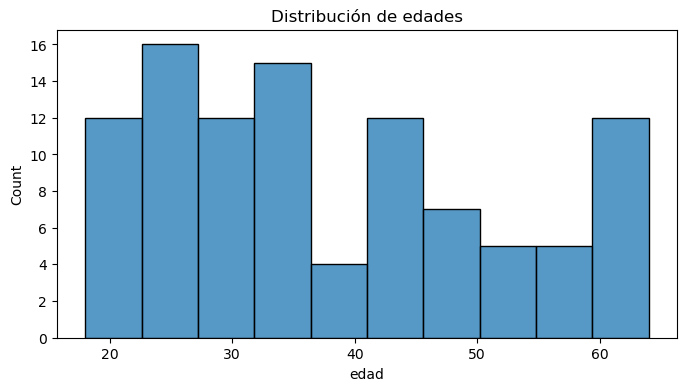

In [8]:
#distribuicion de edades 
plt.figure(figsize=(8,4))
sns.histplot(
    df["edad"],
    bins=10
)
plt.title("Distribución de edades")
plt.show()

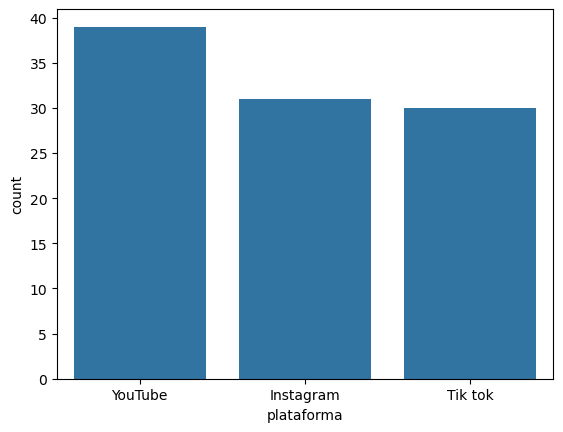

In [10]:
#Usuarios por plataforma 
sns.countplot(
    x = "plataforma",
    data=df
)
plt.show()

In [11]:
#Generamos una copia para contaminarla 
df_sucio = df.copy()

In [12]:
#Le colocamos valores nulos 
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i,"nombre"] = None

In [13]:
df_sucio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_usuario  100 non-null    int64 
 1   nombre      95 non-null     object
 2   correo      100 non-null    object
 3   edad        100 non-null    int64 
 4   seguidores  100 non-null    int64 
 5   plataforma  100 non-null    object
dtypes: int64(3), object(3)
memory usage: 4.8+ KB


In [14]:
#Edades inválidas 
for i in random.sample(range(len(df_sucio)),5):
    df_sucio.loc[i, "edad"] = -10

In [15]:
df_sucio.describe()["edad"]

count    100.000000
mean      35.440000
std       17.061576
min      -10.000000
25%       25.000000
50%       34.000000
75%       47.250000
max       64.000000
Name: edad, dtype: float64

In [17]:
#Seguidores imposibles 
for i in random.sample(range(len(df_sucio)),5): 
    df_sucio.loc[i, "seguidores"] = 50000000

In [18]:
df_sucio.describe()["seguidores"]

count    1.000000e+02
mean     2.524833e+06
std      1.094643e+07
min      1.048000e+03
25%      1.377350e+04
50%      2.877150e+04
75%      4.166100e+04
max      5.000000e+07
Name: seguidores, dtype: float64

In [19]:
#Generamos correo invalidos 
for i in random.sample(range(len(df_sucio)),5): 
    df_sucio.loc[i, "correo"] = "correo_invalido"

In [21]:
df_sucio.describe(include=["object"])

,nombre,correo,plataforma
count,95,100,100
unique,95,96,3
top,Oswaldo Luevano,correo_invalido,YouTube
freq,1,5,39


In [24]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [22]:
df_sucio.isnull().sum()

id_usuario    0
nombre        5
correo        0
edad          0
seguidores    0
plataforma    0
dtype: int64

In [25]:
#estadisticas
df_sucio.describe(include="all")

,id_usuario,nombre,correo,edad,seguidores,plataforma
count,100.00,95,100,100.00,100.00,100
unique,NaN,95,96,NaN,NaN,3
top,NaN,Oswaldo Luevano,correo_invalido,NaN,NaN,YouTube
freq,NaN,1,5,NaN,NaN,39
mean,50.50,NaN,NaN,35.44,2524832.74,NaN
std,29.01,NaN,NaN,17.06,10946429.98,NaN
min,1.00,NaN,NaN,-10.00,1048.00,NaN
25%,25.75,NaN,NaN,25.00,13773.50,NaN
50%,50.50,NaN,NaN,34.00,28771.50,NaN
75%,75.25,NaN,NaN,47.25,41661.00,NaN
